# Probabilistic equivalence analysis

## Accuracy analysis

In [4]:
from src import Plot, successRatioBy, printMeanDecrease, printAccuracy

cancellationPath = "data/probabilisticEq/cancellation_accuracy.csv"
commutativePath = "data/probabilisticEq/commutation_accuracy.csv"
idempotencyPath = "data/probabilisticEq/idempotency_accuracy.csv"


def addSuccessRatioComparison(plot, csvPath):
    plot.add(
        csvPath,
        lambda data: successRatioBy(
            data,
            xColumn="numOfStates",
            filters={"useSrs": 0},
        ),
        label="Without SRS",
    )
    plot.add(
        csvPath,
        lambda data: successRatioBy(
            data,
            xColumn="numOfStates",
            filters={"useSrs": 1},
        ),
        label="With SRS",
    )

## Commutativity

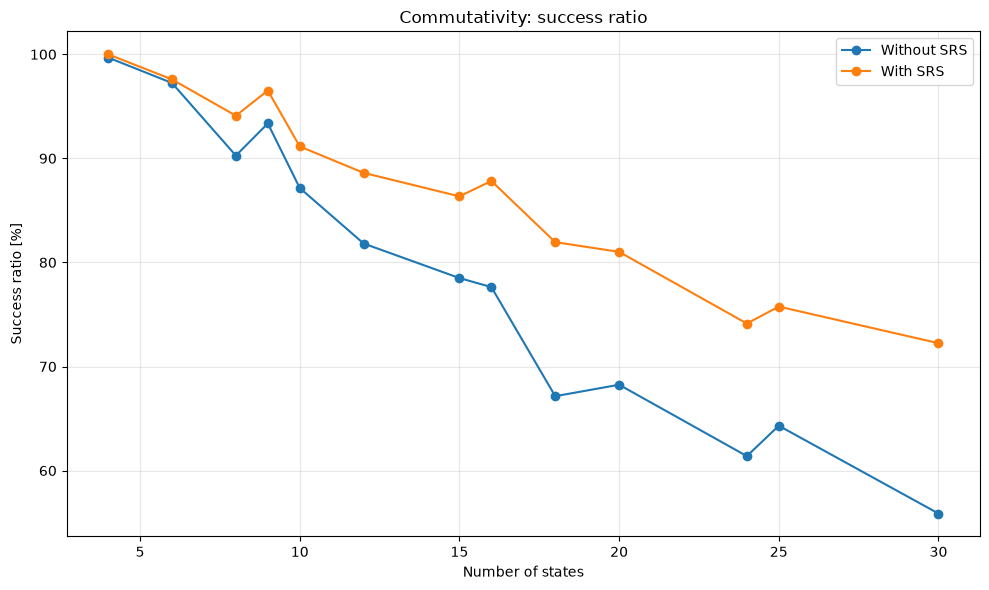

In [5]:
commutativitySuccessPlot = Plot(
    title="Commutativity: success ratio",
    xLabel="Number of states",
    yLabel="Success ratio [%]",
)
addSuccessRatioComparison(commutativitySuccessPlot, commutativePath)
commutativitySuccessPlot.draw()

In [6]:
printAccuracy(commutativePath)

Accuracy without SRS 80.78% and with SRS 88.00%  (all automata)
Average accurtacy gain 8.93%  (all automata)

Accuracy without SRS 88.16% and with SRS 92.45%  (automata with at most 15 states)
Average accurtacy gain 4.86%  (automata with at most 15 states)

Accuracy without SRS 60.57% and with SRS 74.07%  (automata with more than 20 states)
Average accurtacy gain 22.29%  (automata with more than 20 states)


## Cancellation

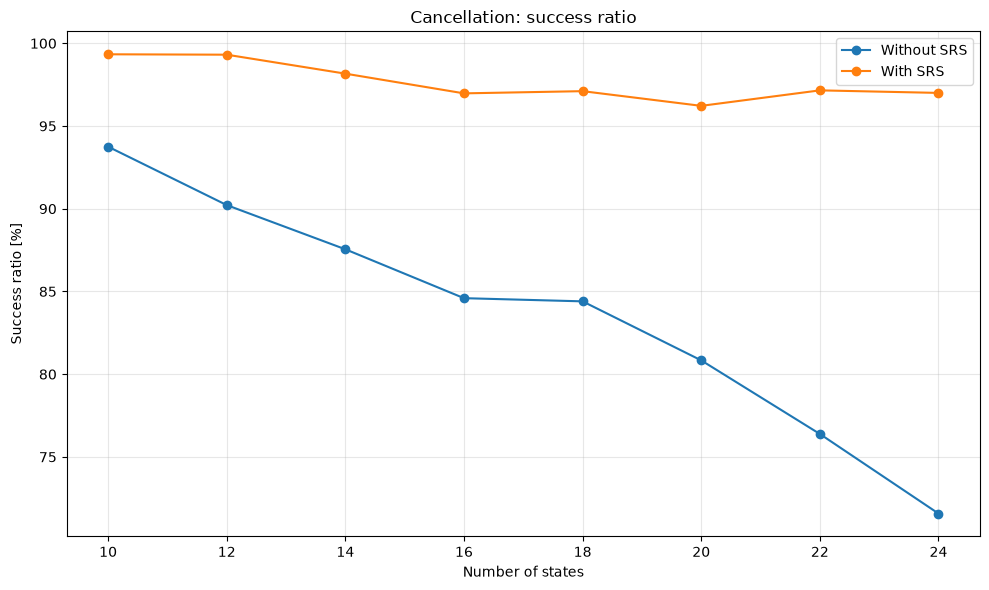

In [7]:
cancellationSuccessPlot = Plot(
    title="Cancellation: success ratio",
    xLabel="Number of states",
    yLabel="Success ratio [%]",
)
addSuccessRatioComparison(cancellationSuccessPlot, cancellationPath)
cancellationSuccessPlot.draw()

In [8]:
printAccuracy(cancellationPath)

Accuracy without SRS 83.67% and with SRS 97.65%  (all automata)
Average accurtacy gain 16.71%  (all automata)

Accuracy without SRS 90.50% and with SRS 98.93%  (automata with at most 15 states)
Average accurtacy gain 9.32%  (automata with at most 15 states)

Accuracy without SRS 73.88% and with SRS 97.07%  (automata with more than 20 states)
Average accurtacy gain 31.40%  (automata with more than 20 states)


## Idempotency

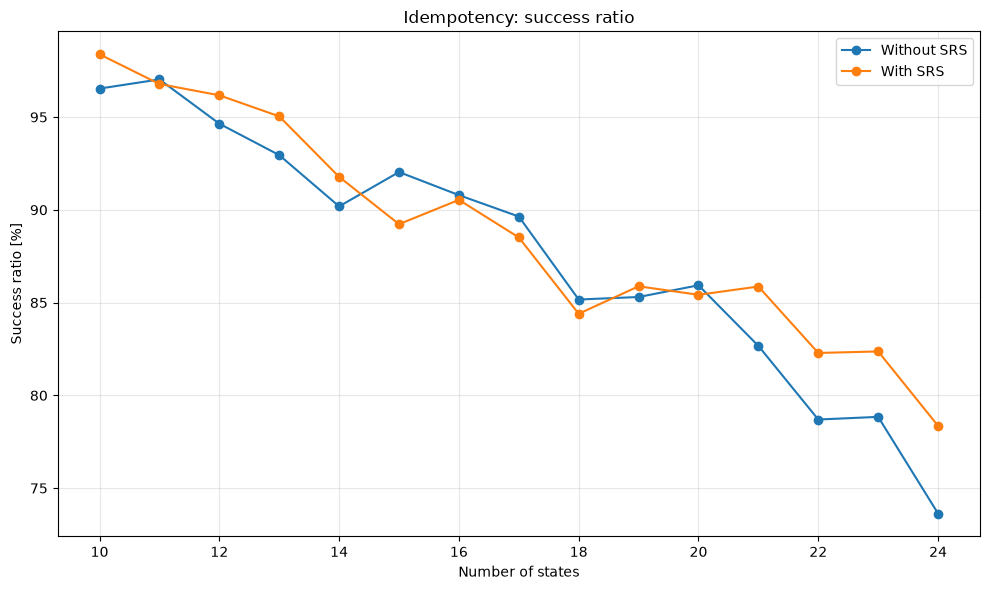

In [9]:
idempotencySuccessPlot = Plot(
    title="Idempotency: success ratio",
    xLabel="Number of states",
    yLabel="Success ratio [%]",
)
addSuccessRatioComparison(idempotencySuccessPlot, idempotencyPath)
idempotencySuccessPlot.draw()

In [10]:
printAccuracy(idempotencyPath)

Accuracy without SRS 87.63% and with SRS 88.75%  (all automata)
Average accurtacy gain 1.27%  (all automata)

Accuracy without SRS 93.96% and with SRS 94.58%  (automata with at most 15 states)
Average accurtacy gain 0.66%  (automata with at most 15 states)

Accuracy without SRS 78.40% and with SRS 82.16%  (automata with more than 20 states)
Average accurtacy gain 4.80%  (automata with more than 20 states)


## Equivalence analysis

In [11]:
from src import Plot, meanBy, printMeanDecrease
import pandas as pd

cancellationPath = (
    "data/exactEq/cancellation_increasing_number_of_states.csv"
)
commutativePath = (
    "data/exactEq/commutation_increasing_number_of_states.csv"
)
idempotencyPath = (
    "data/exactEq/idempotency_increasing_number_of_states.csv"
)


def addMeanComparison(plot, csvPath, yColumn, scale=1):
    plot.add(
        csvPath,
        lambda data: meanBy(
            data,
            xColumn="numOfStates",
            yColumn=yColumn,
            filters={"useSrs": 0},
        ) / scale,
        label="Without SRS",
    )
    plot.add(
        csvPath,
        lambda data: meanBy(
            data,
            xColumn="numOfStates",
            yColumn=yColumn,
            filters={"useSrs": 1},
        ) / scale,
        label="With SRS",
    )

### Commutativity

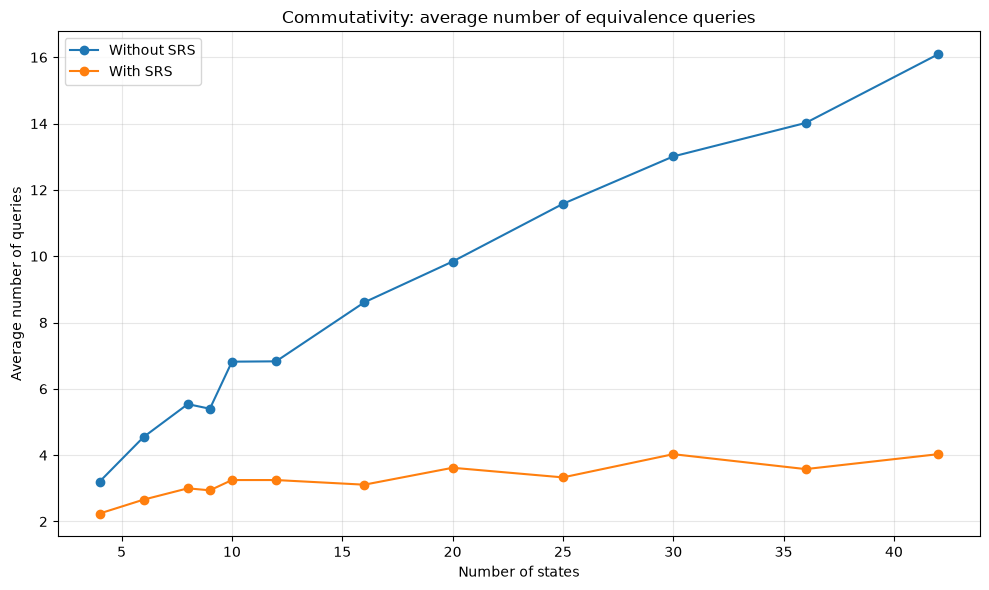

In [12]:
commutativityQueriesPlot = Plot(
    title="Commutativity: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    commutativityQueriesPlot,
    commutativePath,
    yColumn="equivalenceQueryCount",
)
commutativityQueriesPlot.draw()

In [13]:
printMeanDecrease(commutativePath)

Average procentage reduction in equivalence queries 62.99%


## Cancellation

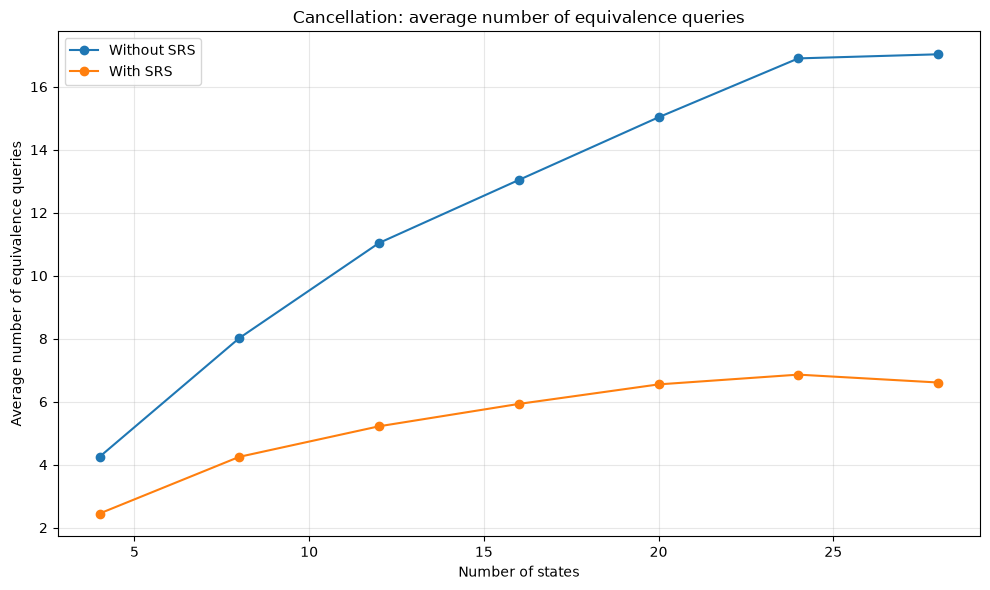

In [14]:
cancellationQueriesPlot = Plot(
    title="Cancellation: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of equivalence queries",
)
addMeanComparison(
    cancellationQueriesPlot,
    cancellationPath,
    yColumn="equivalenceQueryCount",
)
cancellationQueriesPlot.draw()

In [15]:
printMeanDecrease(cancellationPath)

Average procentage reduction in equivalence queries 55.61%


## Idempotency

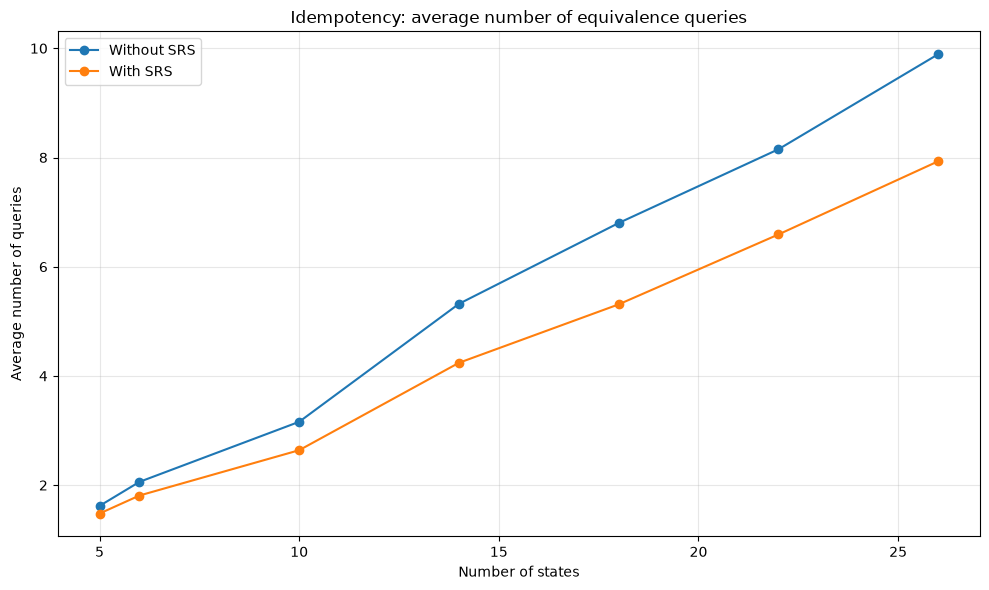

In [16]:
idempotencyQueriesPlot = Plot(
    title="Idempotency: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    idempotencyQueriesPlot,
    idempotencyPath,
    yColumn="equivalenceQueryCount",
)
idempotencyQueriesPlot.draw()

In [17]:
printMeanDecrease(idempotencyPath)

Average procentage reduction in equivalence queries 18.92%
